In [3]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import json
import numpy as np
import re
from textstat import flesch_reading_ease
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt

from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

In [ ]:
data = ''

with open('/Users/albertzagibin/Documents/University/ML/I_Professional_AI/12/Искусственный ученый/abstracts.json'
          , 'r') as file:
    data = json.load(file)

In [21]:
df_abstract = pd.DataFrame(data.items(), columns=['id', 'text'])

In [22]:
df_abstract.head()

,id,text
0,0,The rapid proliferation of large language mode...
1,1,This work introduces a federated learning (FL)...
2,2,The ability of visual systems to bind features...
3,3,Graph Neural Networks (GNNs) have achieved rem...
4,4,Large Language Model (LLM)-based autonomous ag...


In [5]:
def extract_features(text):
    features = {}
    
    features['text_length'] = len(text)
    features['sentence_count'] = len(re.split(r'[.!?]+', text))
    features['avg_sentence_length'] = features['text_length'] / max(features['sentence_count'], 1)
    
    words = text.split()
    features['word_count'] = len(words)
    features['unique_word_ratio'] = len(set(words)) / max(len(words), 1)
    
    features['flesch_reading_ease'] = flesch_reading_ease(text)
    
    features['comma_freq'] = text.count(',') / max(len(words), 1)
    features['exclamation_freq'] = text.count('!') / max(len(words), 1)
    
    features['avg_word_length'] = np.mean([len(w) for w in words]) if words else 0
    
    return features

df_features = df_abstract['text'].apply(extract_features).apply(pd.Series)

In [6]:
df_features.head()

,text_length,sentence_count,avg_sentence_length,word_count,unique_word_ratio,flesch_reading_ease,comma_freq,exclamation_freq,avg_word_length
0,1951.0,12.0,162.583333,264.0,0.719697,5.896981,0.087121,0.0,6.393939
1,1229.0,9.0,136.555556,162.0,0.814815,6.173342,0.049383,0.0,6.592593
2,1989.0,12.0,165.750000,273.0,0.714286,9.615610,0.047619,0.0,6.278388
3,1534.0,9.0,170.444444,205.0,0.751220,9.974893,0.053659,0.0,6.478049
4,1001.0,9.0,111.222222,132.0,0.833333,10.565988,0.075758,0.0,6.590909


In [15]:
def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    elif torch.backends.mps.is_available():
        return torch.device("mps")
    else:
        return torch.device("cpu")


device = get_device()
print(f"Using device: {device}")

Using device: mps


In [16]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

def calculate_perplexity(text, model, tokenizer, device):
    encodings = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        max_length=512
    )
    encodings = {k: v.to(device) for k, v in encodings.items()}

    with torch.no_grad():
        outputs = model(**encodings, labels=encodings["input_ids"])
        loss = outputs.loss

    return torch.exp(loss).item()

df_abstract['perplexity'] = df_abstract['text'].apply(
    lambda x: calculate_perplexity(x, model, tokenizer, device)
)

In [18]:
df_abstract.head()

,id,text,cluster,perplexity
0,0,The rapid proliferation of large language mode...,1,40.867954
1,1,This work introduces a federated learning (FL)...,0,52.672848
2,2,The ability of visual systems to bind features...,1,46.905537
3,3,Graph Neural Networks (GNNs) have achieved rem...,0,51.095509
4,4,Large Language Model (LLM)-based autonomous ag...,0,72.021599


In [19]:
df_features['perplexity'] = df_abstract['perplexity']

In [20]:
df_features.head()

,text_length,sentence_count,avg_sentence_length,word_count,unique_word_ratio,flesch_reading_ease,comma_freq,exclamation_freq,avg_word_length,perplexity
0,1951.0,12.0,162.583333,264.0,0.719697,5.896981,0.087121,0.0,6.393939,40.867954
1,1229.0,9.0,136.555556,162.0,0.814815,6.173342,0.049383,0.0,6.592593,52.672848
2,1989.0,12.0,165.750000,273.0,0.714286,9.615610,0.047619,0.0,6.278388,46.905537
3,1534.0,9.0,170.444444,205.0,0.751220,9.974893,0.053659,0.0,6.478049,51.095509
4,1001.0,9.0,111.222222,132.0,0.833333,10.565988,0.075758,0.0,6.590909,72.021599


In [22]:
df_features.describe()

,text_length,sentence_count,avg_sentence_length,word_count,unique_word_ratio,flesch_reading_ease,comma_freq,exclamation_freq,avg_word_length,perplexity
count,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000,4050.000000
mean,1649.825432,11.297531,149.783144,217.855802,0.767300,8.164668,0.063515,0.000026,6.560329,57.322585
std,445.001259,3.520763,29.382095,57.919460,0.047234,10.880903,0.021032,0.000472,0.343136,15.799450
min,38.000000,2.000000,19.000000,8.000000,0.578035,-41.008684,0.000000,0.000000,3.875000,18.878004
25%,1289.000000,9.000000,129.876838,171.000000,0.733630,1.040498,0.049107,0.000000,6.349369,46.527796
50%,1670.500000,11.000000,149.181818,222.000000,0.763323,8.026293,0.060748,0.000000,6.557877,55.401859
75%,2011.000000,13.000000,169.210714,265.000000,0.800000,15.426115,0.074982,0.000000,6.777778,65.259529
max,3028.000000,37.000000,302.285714,387.000000,1.000000,103.540000,0.159091,0.019084,8.607595,194.620117


In [1]:
PATH = '/Users/albertzagibin/Documents/University/ML/I_Professional_AI/12/df_features.csv'
# df_features.to_csv(PATH)

In [4]:
df_features = pd.read_csv(PATH, sep=',', usecols=range(1,11))

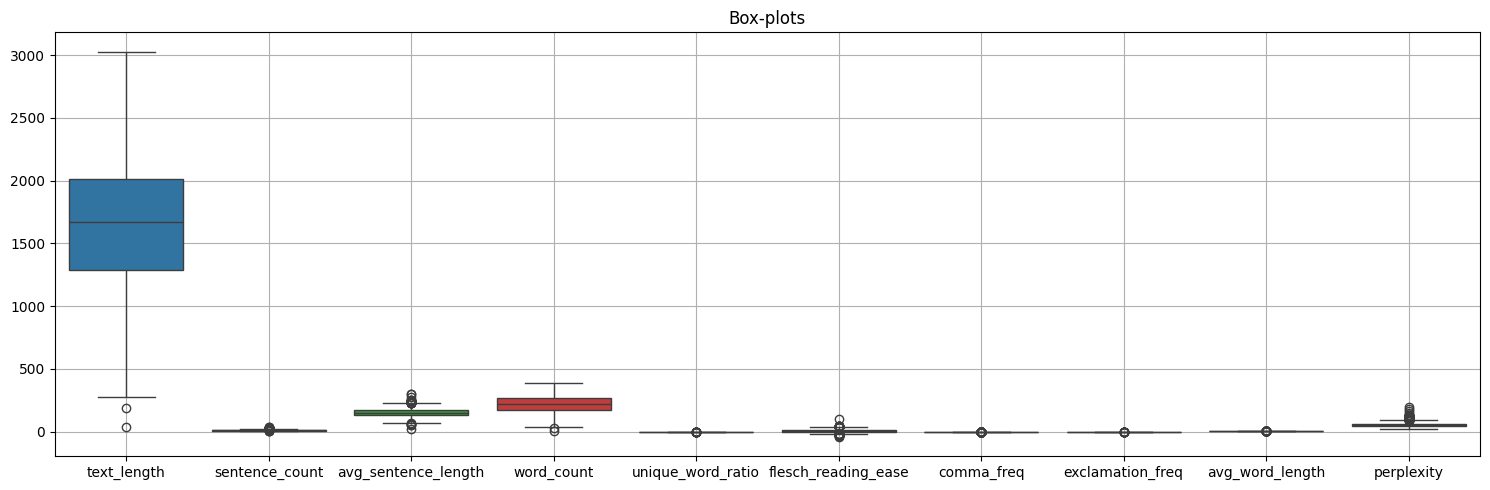

In [5]:
plt.figure(figsize=(15, 5))
sns.boxplot(data=df_features)
plt.title('Box-plots')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 2000x1800 with 0 Axes>

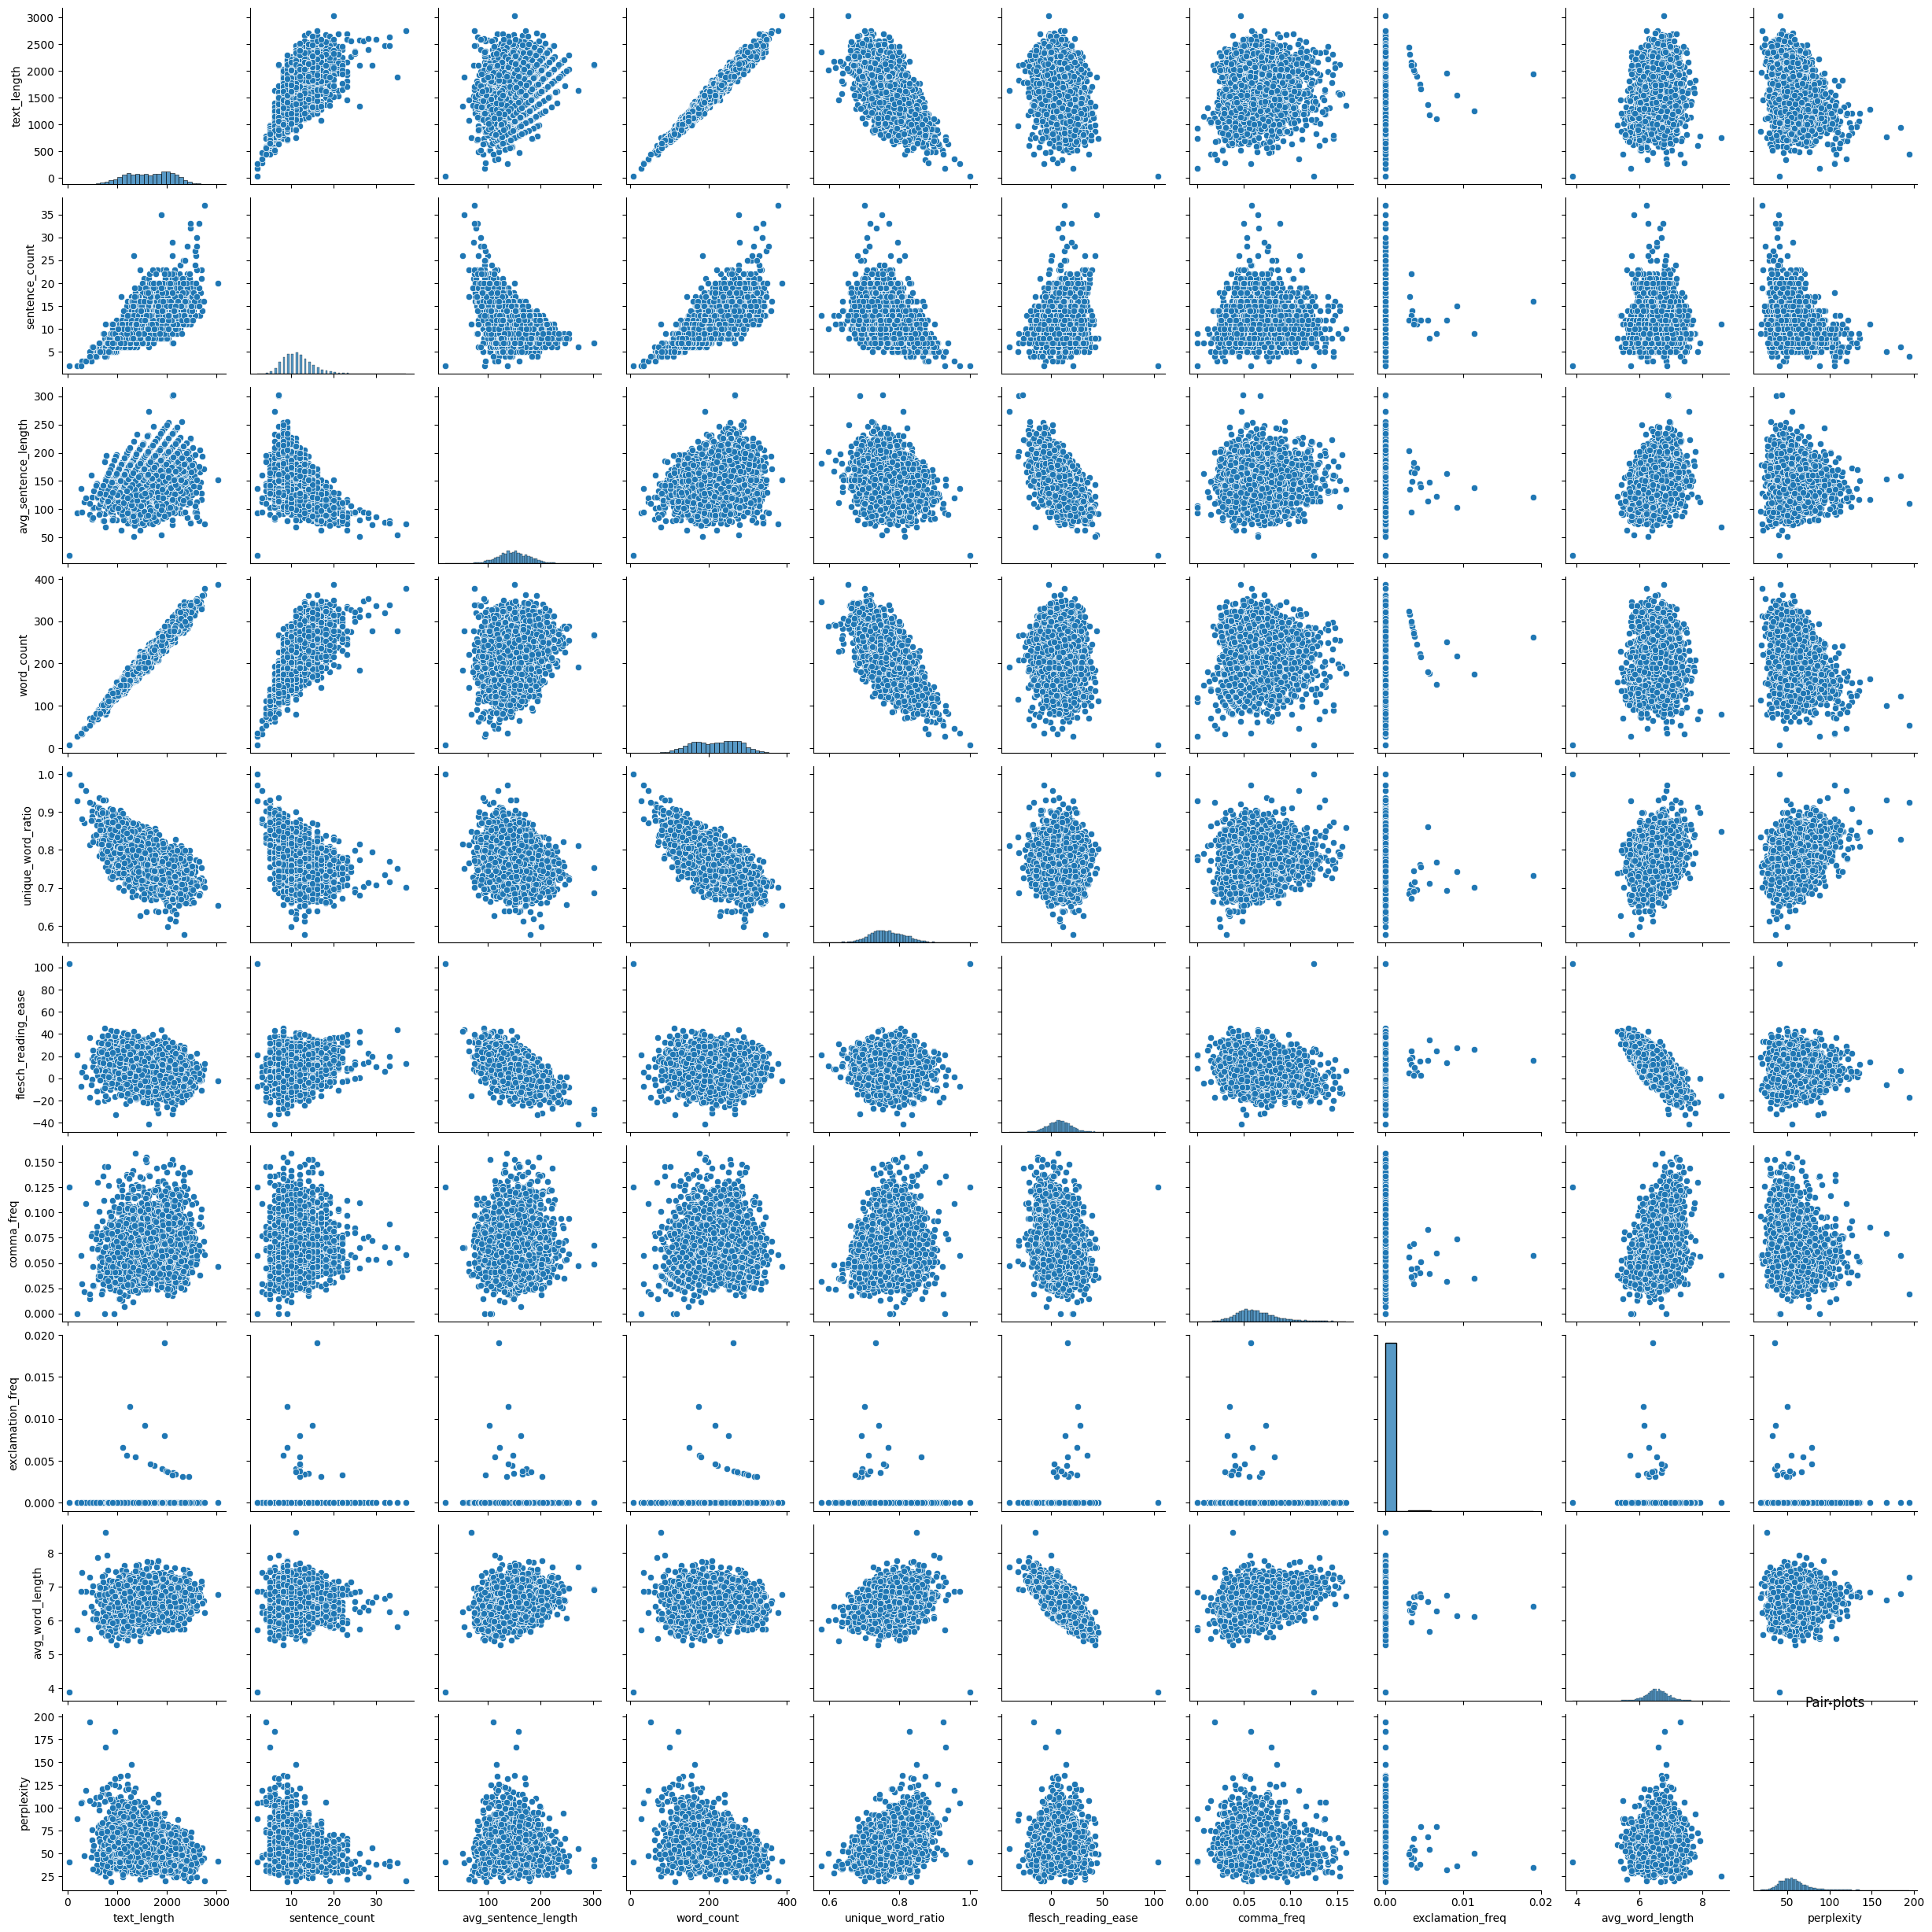

In [39]:
plt.figure(figsize=(20, 18))
sns.pairplot(data=df_features)
plt.title('Pair-plots')
plt.show()

<Axes: >

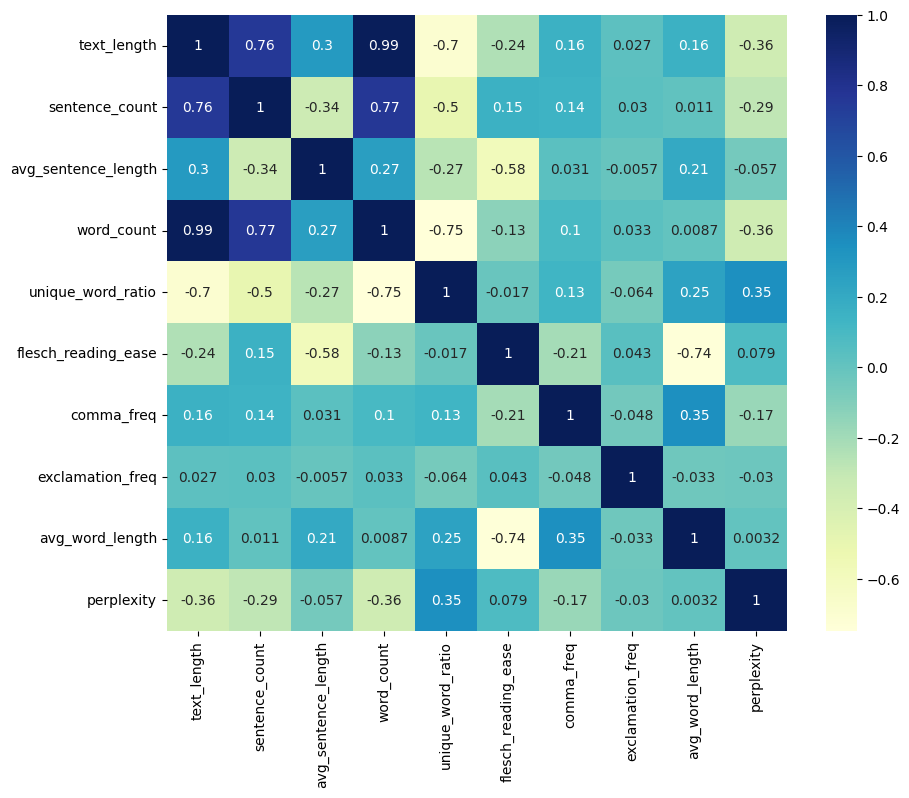

In [49]:
corr_m = df_features.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_m, cmap="YlGnBu", annot=True)

In [7]:
X = df_features.fillna(0)
X_scaled = StandardScaler().fit_transform(X)

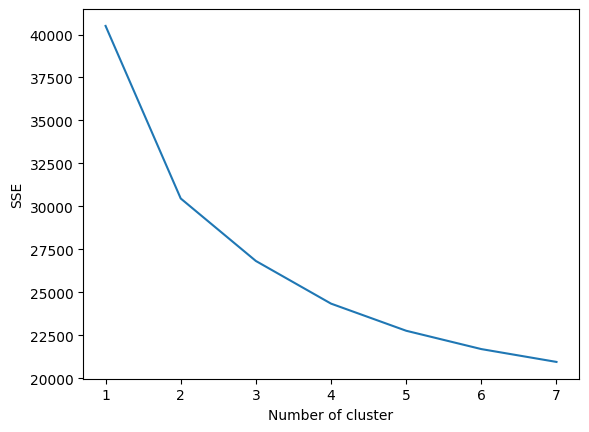

In [5]:
sse = {}

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(X_scaled)
    label = kmeans.labels_
    sse[k] = kmeans.inertia_ 

plt.figure()
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.ylabel("SSE")
plt.show()

In [6]:
for k in range(2, 5):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(X_scaled)
    label = kmeans.labels_
    sil_coeff = silhouette_score(X_scaled, label)
    print("For k={}, The Silhouette Coefficient is {}".format(k, sil_coeff))

For k=2, The Silhouette Coefficient is 0.25056106301212006
For k=3, The Silhouette Coefficient is 0.19680269085517993
For k=4, The Silhouette Coefficient is 0.17703989447983384


In [8]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(X_scaled)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [9]:
agg_clustering = AgglomerativeClustering(n_clusters=2)
agg_clustering.fit(X_scaled) 

,n_clusters,2
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [10]:
k = 2 * X_scaled.shape[1]

for eps in np.linspace(0.01, 1, 100):
    labels = DBSCAN(eps=eps, min_samples=k).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    if n_clusters == 2:
       print(f"eps={eps:.2f} → clusters={n_clusters}")

eps=0.80 → clusters=2
eps=0.81 → clusters=2
eps=0.82 → clusters=2
eps=0.83 → clusters=2
eps=0.88 → clusters=2
eps=0.90 → clusters=2
eps=0.91 → clusters=2
eps=0.92 → clusters=2
eps=0.93 → clusters=2
eps=0.94 → clusters=2


In [11]:
dbscan_cl = DBSCAN(eps=0.94, min_samples=k) 
dbscan_cl.fit(X_scaled)  

,eps,0.94
,min_samples,20
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [ ]:
kmeans_clusters = kmeans.labels_
agg_clusters = agg_clustering.labels_
dbscan_clusters = dbscan_cl.labels_ 

In [13]:
np.unique(dbscan_clusters)

array([-1,  0,  1])

In [14]:
dbscan_clusters[dbscan_clusters == -1] = 1 

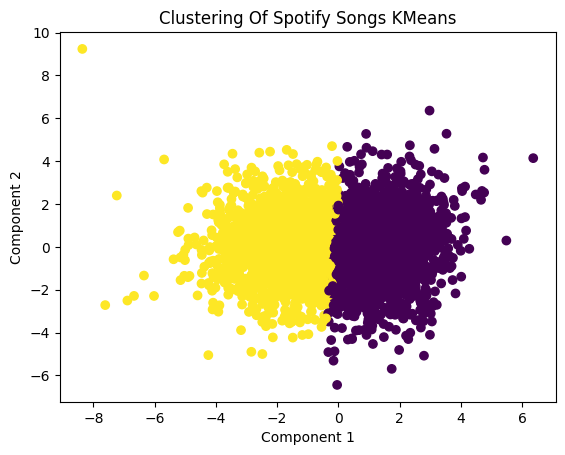

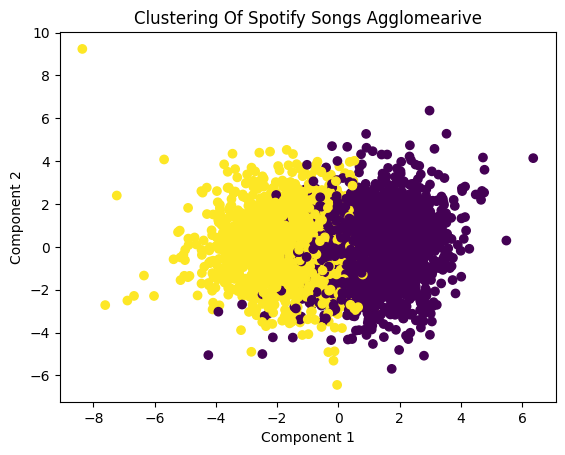

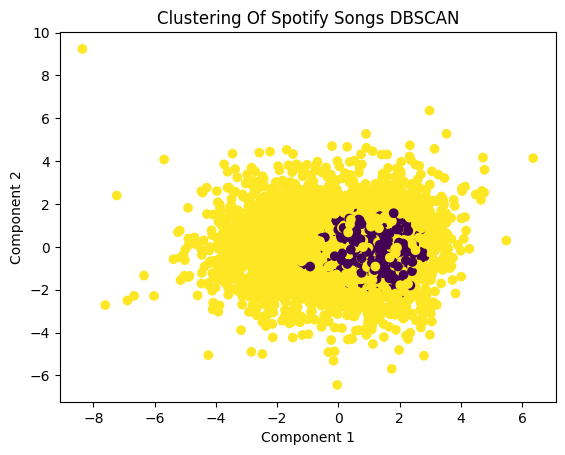

In [15]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

def plot_clusters(clusters, title=None):
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=clusters)
    plt.title(f'Clustering Of Spotify Songs {title}')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.show()


plot_clusters(kmeans_clusters, title='KMeans')
plot_clusters(agg_clusters, title='Agglomearive')
plot_clusters(dbscan_clusters, title='DBSCAN')

In [17]:
def print_each_cluster(cluster_, rows=1, cols=2, title=None):
    unique_clusters = np.unique(cluster_)
    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 4), sharex=True, sharey=True)

    if title is not None:
        plt.suptitle(title, fontsize=16)

    axs = axs.flatten()
    for i, cluster in enumerate(unique_clusters):
        df_cluster = X_2d[cluster_ == cluster]
        
        df_other_clusters = X_2d[cluster_ != cluster]
        
        axs[i].scatter(df_other_clusters[:, 0], df_other_clusters[:, 1], c='gray', label='Other clusters', alpha=0.5)
        
        axs[i].scatter(df_cluster[:, 0], df_cluster[:, 1], c='red', label='Cluster {}'.format(cluster))
        
        axs[i].set_xlabel('Component 1')
        axs[i].set_ylabel('Component 2')
        
        axs[i].legend()

    plt.tight_layout()
    plt.show()

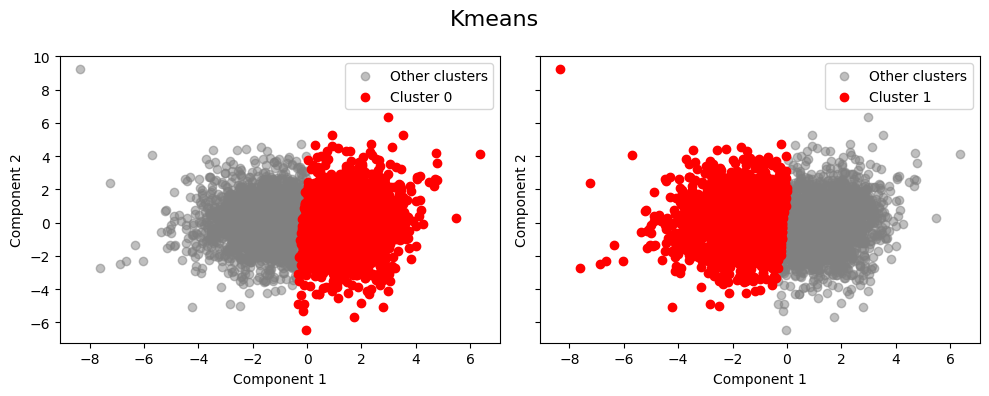

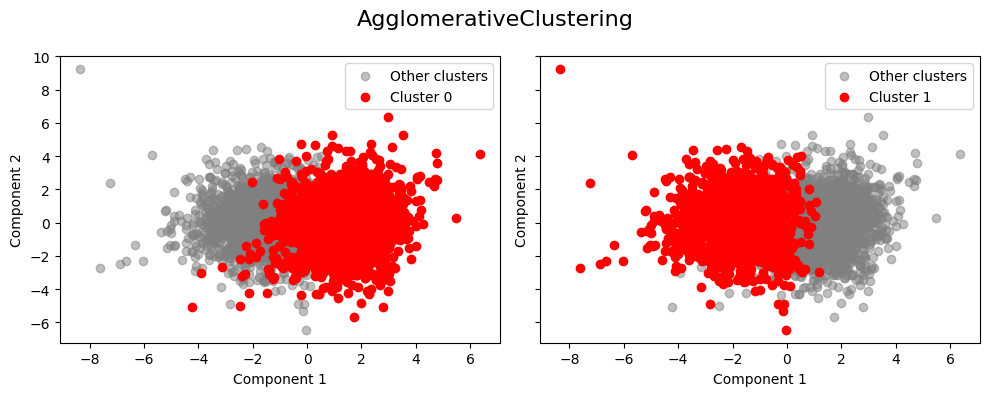

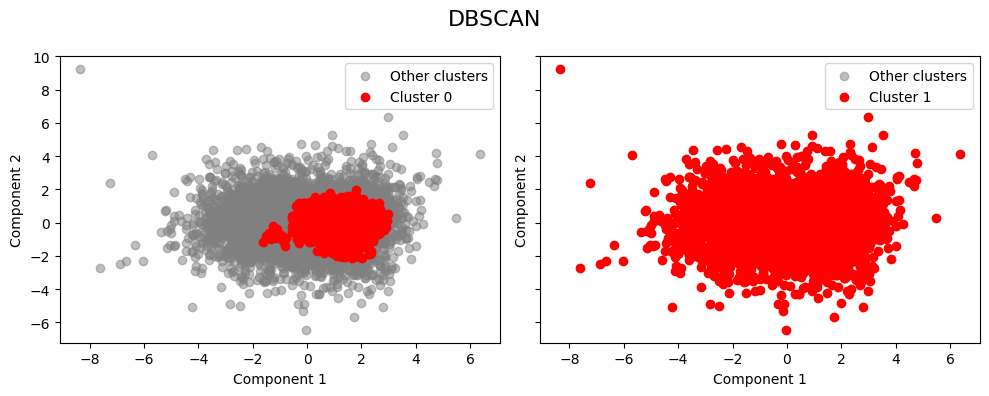

In [18]:
print_each_cluster(kmeans_clusters, title='Kmeans')
print_each_cluster(agg_clusters, title='AgglomerativeClustering')
print_each_cluster(dbscan_clusters, title='DBSCAN')

In [23]:
df_abstract['kmeans_score'] = kmeans_clusters
df_abstract['agg_score'] = agg_clusters
df_abstract['dbscan_score'] = dbscan_clusters

In [24]:
df_abstract['kmeans_score'].value_counts()

kmeans_score
0    2204
1    1846
Name: count, dtype: int64

In [25]:
df_abstract['agg_score'].value_counts()

agg_score
0    2357
1    1693
Name: count, dtype: int64

In [26]:
df_abstract['dbscan_score'].value_counts()

dbscan_score
1    3216
0     834
Name: count, dtype: int64

In [27]:
def compute_silhouette_score(X, label, title):
    sil_coeff = silhouette_score(X, label)
    print(f"For {title}, The Silhouette Coefficient is {sil_coeff}")

In [28]:
compute_silhouette_score(X_scaled, kmeans_clusters, title='Kmeans')
compute_silhouette_score(X_scaled, agg_clusters, title='AgglomerativeClustering')
compute_silhouette_score(X_scaled, dbscan_clusters, title='DBSCAN')

For Kmeans, The Silhouette Coefficient is 0.2505853896886199
For AgglomerativeClustering, The Silhouette Coefficient is 0.22631407417851007
For DBSCAN, The Silhouette Coefficient is -0.03214913927933434


In [42]:
df_abstract.head()

,id,text,kmeans_score,agg_score,dbscan_score
0,0,The rapid proliferation of large language mode...,0,0,1
1,1,This work introduces a federated learning (FL)...,1,1,1
2,2,The ability of visual systems to bind features...,0,0,0
3,3,Graph Neural Networks (GNNs) have achieved rem...,1,0,0
4,4,Large Language Model (LLM)-based autonomous ag...,1,1,1
